In [13]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LinearRegression

In [14]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
from sklearn.metrics import mean_squared_error

In [15]:
df = pd.read_csv("https://raw.githubusercontent.com/Laxminarayen/InceptezGenAI-Batch26/refs/heads/main/25.%20Decision%20Tree%20Handson%20-%20Regression/IT_Salary_dataset/IT_Salaries_Dataset.csv")

In [16]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [17]:
df['job_title'].value_counts()

,count
job_title,
Data Engineer,1040
Data Scientist,840
Data Analyst,612
Machine Learning Engineer,289
Analytics Engineer,103
...,...
Principal Data Architect,1
Head of Machine Learning,1
Cloud Data Architect,1


In [18]:
df.isna().sum()

,0
work_year,0
experience_level,0
employment_type,0
job_title,0
salary,0
salary_currency,0
salary_in_usd,0
employee_residence,0
remote_ratio,0
company_location,0


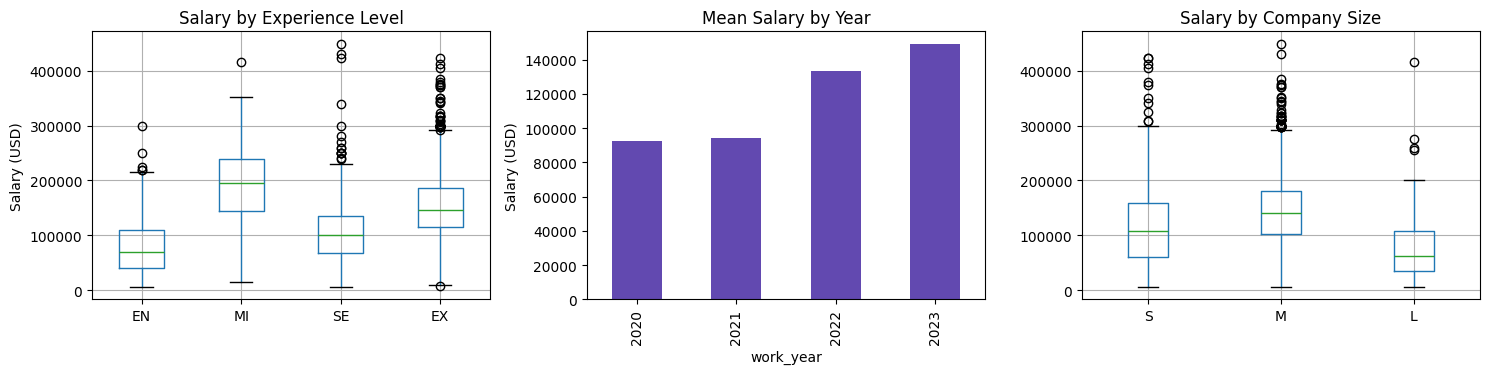

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

order = ['EN', 'MI', 'SE', 'EX']
df.boxplot(column='salary_in_usd', by='experience_level', ax=axes[0], positions=range(len(order)))
axes[0].set_xticks(range(len(order)))
axes[0].set_xticklabels(order)
axes[0].set_title('Salary by Experience Level')
axes[0].set_xlabel('')
axes[0].set_ylabel('Salary (USD)')

df.groupby('work_year')['salary_in_usd'].mean().plot(kind='bar', ax=axes[1], color='#6249B0')
axes[1].set_title('Mean Salary by Year')
axes[1].set_ylabel('Salary (USD)')

size_order = ['S', 'M', 'L']
df.boxplot(column='salary_in_usd', by='company_size', ax=axes[2], positions=range(len(size_order)))
axes[2].set_xticks(range(len(size_order)))
axes[2].set_xticklabels(size_order)
axes[2].set_title('Salary by Company Size')
axes[2].set_xlabel('')

plt.suptitle('')
plt.tight_layout()
plt.show()

In [20]:
df = df.drop_duplicates().reset_index(drop = True)

In [21]:
def iqr_bounds(values):
    q1, q3 = values.quantile(0.25), values.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

is_outlier = pd.Series(False, index=df.index)
print(f"{'Level':<6} {'Lower bound':>14} {'Upper bound':>14} {'Outliers':>10}")
for level, grp in df.groupby('experience_level'):
    lo, hi = iqr_bounds(grp['salary_in_usd'])
    mask = (grp['salary_in_usd'] < lo) | (grp['salary_in_usd'] > hi)
    is_outlier.loc[grp.index] = mask
    print(f"{level:<6} {lo:>14,.0f} {hi:>14,.0f} {mask.sum():>10}")

df_clean = df[~is_outlier].reset_index(drop=True)
print("\nRows remaining after outlier removal:", f"{len(df_clean):,}")

Level     Lower bound    Upper bound   Outliers
EN            -70,275        202,165          8
EX              8,029        371,183          1
MI            -44,783        241,270         11
SE             -5,225        307,375         21

Rows remaining after outlier removal: 2,543


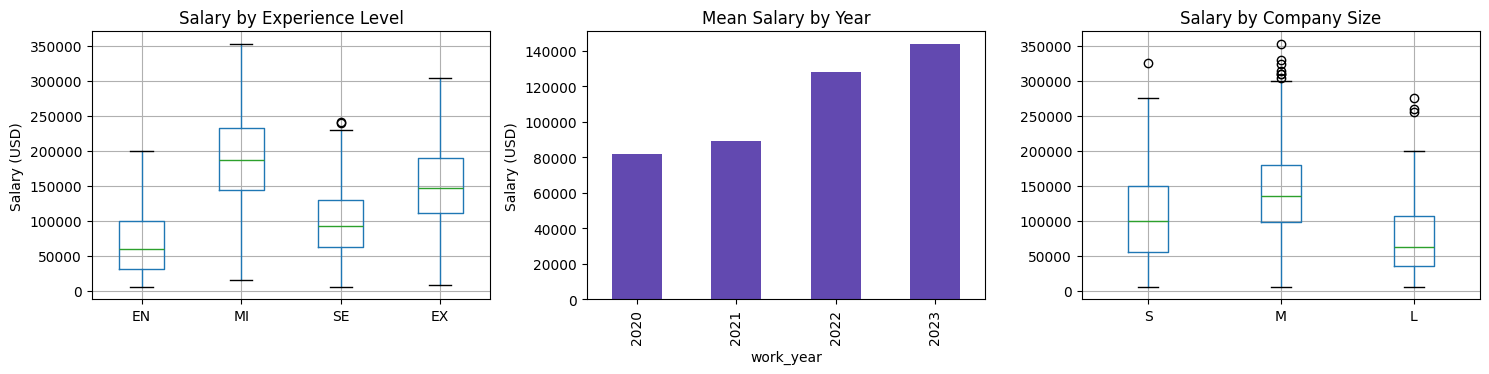

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

order = ['EN', 'MI', 'SE', 'EX']
df_clean.boxplot(column='salary_in_usd', by='experience_level', ax=axes[0], positions=range(len(order)))
axes[0].set_xticks(range(len(order)))
axes[0].set_xticklabels(order)
axes[0].set_title('Salary by Experience Level')
axes[0].set_xlabel('')
axes[0].set_ylabel('Salary (USD)')

df_clean.groupby('work_year')['salary_in_usd'].mean().plot(kind='bar', ax=axes[1], color='#6249B0')
axes[1].set_title('Mean Salary by Year')
axes[1].set_ylabel('Salary (USD)')

size_order = ['S', 'M', 'L']
df_clean.boxplot(column='salary_in_usd', by='company_size', ax=axes[2], positions=range(len(size_order)))
axes[2].set_xticks(range(len(size_order)))
axes[2].set_xticklabels(size_order)
axes[2].set_title('Salary by Company Size')
axes[2].set_xlabel('')

plt.suptitle('')
plt.tight_layout()
plt.show()

In [ ]:
df_clean['company_location'].value_counts()

In [39]:
def bucket_rare(series, top_n):
    top_categories = series.value_counts().nlargest(top_n).index
    #print(top_categories)
    return series.where(series.isin(top_categories), other='Other')

In [ ]:
bucket_rare(df_clean['job_title'],11)

In [41]:
df_clean['job_title'].value_counts().loc[df_clean['job_title'].value_counts()>25].shape

(11,)

In [42]:
df_clean['job_title_grouped'] = bucket_rare(df_clean['job_title'], top_n=11)
df_clean['company_location_grouped'] = bucket_rare(df_clean['company_location'], top_n=8)

In [ ]:
df_clean['company_location_grouped'].value_counts()

In [ ]:
df_clean['company_location'].value_counts()

In [46]:
numeric_features  = ['work_year', 'remote_ratio']
ordinal_features  = ['experience_level', 'company_size']
nominal_features  = ['employment_type', 'job_title_grouped', 'company_location_grouped']

In [47]:
feature_cols = numeric_features + ordinal_features + nominal_features
target_col = 'salary_in_usd'

X = df_clean[feature_cols]
y = df_clean[target_col]

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [51]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler

In [52]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('ord', OrdinalEncoder(categories=[['EN', 'MI', 'SE', 'EX'], ['S', 'M', 'L']]), ordinal_features),
    ('nom', OneHotEncoder(handle_unknown='ignore'), nominal_features),
])
preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['work_year', 'remote_ratio']),
                                ('ord',
                                 OrdinalEncoder(categories=[['EN', 'MI', 'SE',
                                                             'EX'],
                                                            ['S', 'M', 'L']]),
                                 ['experience_level', 'company_size']),
                                ('nom', OneHotEncoder(handle_unknown='ignore'),
                                 ['employment_type', 'job_title_grouped',
                                  'company_location_grouped'])])

In [71]:
X_train = preprocessor.fit_transform(X_train)

In [53]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
def evaluate(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name:<28} RMSE = ${rmse:>9,.0f}   MAE = ${mae:>9,.0f}   R² = {r2:.3f}")
    return {'model': model_name, 'rmse': rmse, 'mae': mae, 'r2': r2}

A hyperparameter is a configuration setting that you choose before training a machine learning model to control how the algorithm learns.

In [54]:
tree_pipe = Pipeline([('prep',preprocessor),("model",DecisionTreeRegressor())])

In [55]:
tree_pipe.fit(X_train, y_train)
pred = tree_pipe.predict(X_test)

In [57]:
evaluate(y_test, pred, "DecsionTree")

DecsionTree                  RMSE = $   47,625   MAE = $   37,213   R² = 0.406


{'model': 'DecsionTree',
 'rmse': np.float64(47624.819109024196),
 'mae': 37213.28619896697,
 'r2': 0.406467480773422}

In [ ]:
tree_pipe.named_steps['prep'].get_feature_names_out()

In [62]:
feature_names

array(['num__work_year', 'num__remote_ratio', 'ord__experience_level',
       'ord__company_size', 'nom__employment_type_CT',
       'nom__employment_type_FL', 'nom__employment_type_FT',
       'nom__employment_type_PT',
       'nom__job_title_grouped_Analytics Engineer',
       'nom__job_title_grouped_Applied Scientist',
       'nom__job_title_grouped_Data Analyst',
       'nom__job_title_grouped_Data Architect',
       'nom__job_title_grouped_Data Engineer',
       'nom__job_title_grouped_Data Science Manager',
       'nom__job_title_grouped_Data Scientist',
       'nom__job_title_grouped_ML Engineer',
       'nom__job_title_grouped_Machine Learning Engineer',
       'nom__job_title_grouped_Other',
       'nom__job_title_grouped_Research Engineer',
       'nom__job_title_grouped_Research Scientist',
       'nom__company_location_grouped_BR',
       'nom__company_location_grouped_CA',
       'nom__company_location_grouped_DE',
       'nom__company_location_grouped_ES',
       'nom__co

In [59]:
feature_names = tree_pipe.named_steps['prep'].get_feature_names_out()
tree_model = tree_pipe.named_steps['model']

In [63]:
tree_model

DecisionTreeRegressor()

In [64]:
feature_names

array(['num__work_year', 'num__remote_ratio', 'ord__experience_level',
       'ord__company_size', 'nom__employment_type_CT',
       'nom__employment_type_FL', 'nom__employment_type_FT',
       'nom__employment_type_PT',
       'nom__job_title_grouped_Analytics Engineer',
       'nom__job_title_grouped_Applied Scientist',
       'nom__job_title_grouped_Data Analyst',
       'nom__job_title_grouped_Data Architect',
       'nom__job_title_grouped_Data Engineer',
       'nom__job_title_grouped_Data Science Manager',
       'nom__job_title_grouped_Data Scientist',
       'nom__job_title_grouped_ML Engineer',
       'nom__job_title_grouped_Machine Learning Engineer',
       'nom__job_title_grouped_Other',
       'nom__job_title_grouped_Research Engineer',
       'nom__job_title_grouped_Research Scientist',
       'nom__company_location_grouped_BR',
       'nom__company_location_grouped_CA',
       'nom__company_location_grouped_DE',
       'nom__company_location_grouped_ES',
       'nom__co

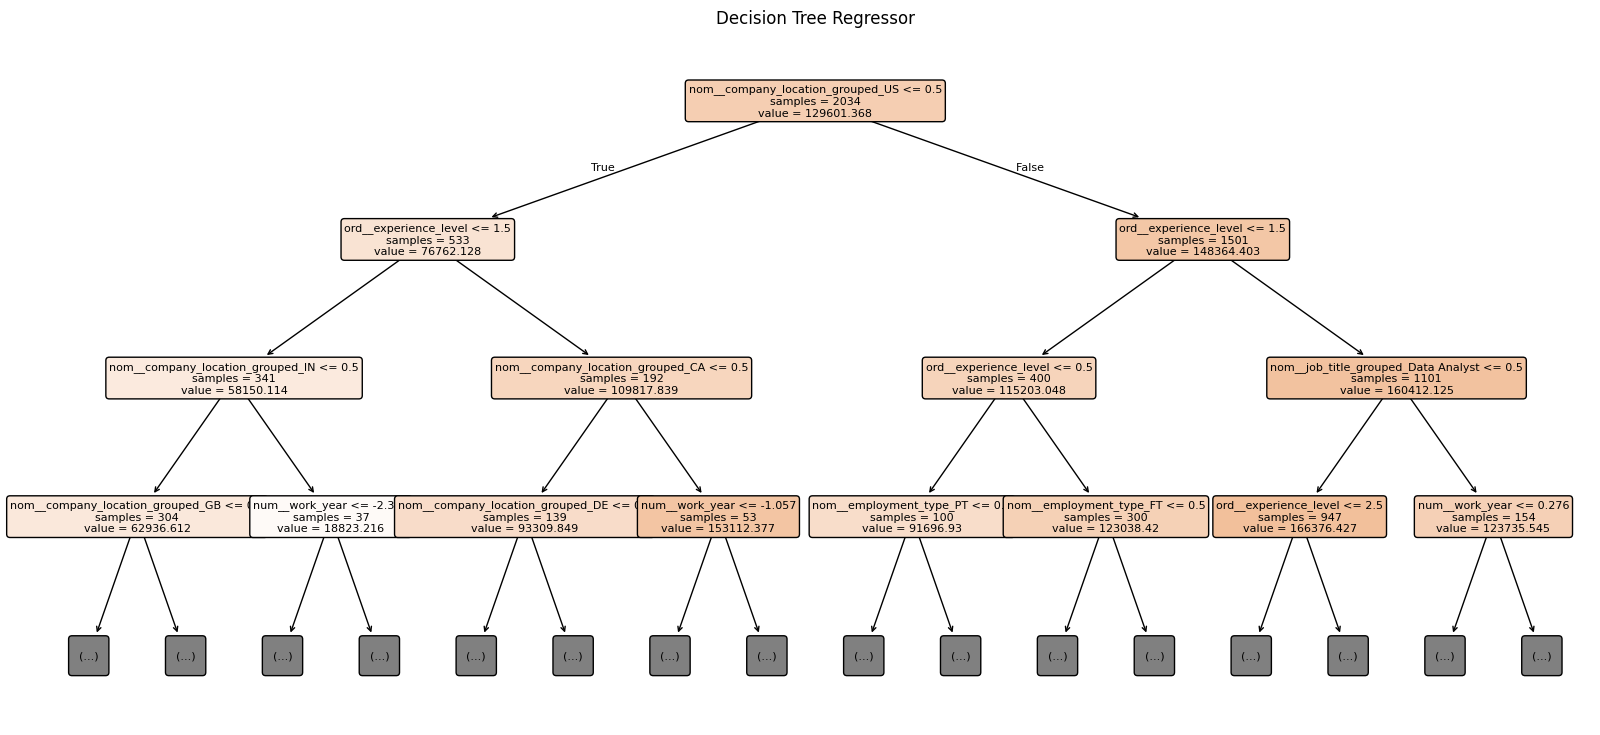

In [61]:
fig_w = max(18, min(tree_model.get_depth(), 4) * 5)
plt.figure(figsize=(fig_w, 9))
plot_tree(tree_model, feature_names=feature_names, filled=True, rounded=True,
          fontsize=8, max_depth=3, impurity=False)
plt.title(f"Decision Tree Regressor")
plt.show()

In [79]:
param_grid = {
    "max_depth":[4,6,8,12,None],
    "min_samples_split":[2,10,20],
    "min_samples_leaf":[1,5,10,20],
}

In [80]:
from sklearn.model_selection import GridSearchCV

In [81]:
grid_search = GridSearchCV(estimator = DecisionTreeRegressor(), param_grid = param_grid, cv = 5, scoring = 'neg_mean_squared_error', verbose=1)

In [82]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


GridSearchCV(cv=5, estimator=DecisionTreeRegressor(),
             param_grid={'max_depth': [4, 6, 8, 12, None],
                         'min_samples_leaf': [1, 5, 10, 20],
                         'min_samples_split': [2, 10, 20]},
             scoring='neg_mean_squared_error', verbose=1)

In [84]:
tree_pipe_new = Pipeline([('prep',preprocessor),("model",DecisionTreeRegressor(max_depth=8, min_samples_leaf=20))])

In [86]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [87]:
tree_pipe_new.fit(X_train, y_train)
pred = tree_pipe_new.predict(X_test)

In [88]:
evaluate(y_test, pred, "DecsionTree")

DecsionTree                  RMSE = $   45,087   MAE = $   35,513   R² = 0.468


{'model': 'DecsionTree',
 'rmse': np.float64(45087.14518291856),
 'mae': 35513.26257730012,
 'r2': 0.46803468609574883}

In [96]:
linear_pipe = Pipeline([('prep', preprocessor), ('model', LinearRegression())])
knn_pipe    = Pipeline([('prep', preprocessor), ('model', KNeighborsRegressor(n_neighbors=10))])

In [98]:
final_results = []
for name, pipe in [('Linear Regression', linear_pipe),(f'KNN Regression (k=10)',knn_pipe),
                    (f'Decision Tree (depth=grid Searched)',tree_pipe_new)]:

    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    final_results.append(evaluate(y_test, pred, name))

results_df = pd.DataFrame(final_results).set_index('model')
results_df

Linear Regression            RMSE = $   44,637   MAE = $   35,089   R² = 0.479
KNN Regression (k=10)        RMSE = $   47,254   MAE = $   37,530   R² = 0.416
Decision Tree (depth=grid Searched) RMSE = $   45,087   MAE = $   35,513   R² = 0.468


,rmse,mae,r2
model,,,
Linear Regression,44636.501241,35088.683296,0.478615
KNN Regression (k=10),47254.441340,37530.207859,0.415663
Decision Tree (depth=grid Searched),45087.145183,35513.262577,0.468035
